<a href="https://colab.research.google.com/github/Emo4ka07/VKR/blob/main/6MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json, os
tf.get_logger().setLevel('ERROR')

# Константы
T = 500.0
TRAIN_N = 500      # dt = 1.0 (стабильно для ОДУ)
DEMO_N = 2000      # dt = 0.25 (для плавных графиков)
X_SCALE = 1000.0
C_SCALE = 1000.0
U_MAX = 500.0
ALPHA_U = 0.005

PARAMS = (0.002, 0.001, 0.49, 0.4632, 0.4425, 505.0, 505.0,
          0.6625, 0.435, 45.0, 30.0, 0.516, 0.45, 0.309, 0.001)

def create_model():
    return tf.keras.Sequential([
        tf.keras.Input(shape=(4,)),
        tf.keras.layers.Dense(32, activation='leaky_relu'),
        tf.keras.layers.Dense(64, activation='leaky_relu'),
        tf.keras.layers.Dense(32, activation='leaky_relu'),
        tf.keras.layers.Dense(1, activation='tanh')
    ])

def dynamics(x, u_scaled, ctrl_idx, p):
    a1, a2, b1, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1 = p
    x1, x2, x3 = x[...,0], x[...,1], x[...,2]
    den1 = d1 + x1 + 1e-6
    den2 = d2 + b1 * tf.square(x2) + 1e-6
    dx1 = r1*x1*(1.0 - (x1 + a1*x2)/K1) - (w1*x1*x3)/den1
    dx2 = r2*x2*(1.0 - (x2 + a2*x1)/K2) - (w2*x2*x3)/den2
    dx3 = (g1*x1*x3)/den1 - (g2*x2*x3)/den2 - m*x3 - m1*tf.square(x3)
    u = tf.reshape(u_scaled, tf.shape(x1))
    if ctrl_idx == 0: dx1 += u
    elif ctrl_idx == 1: dx2 += u
    else: dx3 += u
    return tf.stack([dx1, dx2, dx3], axis=-1)

def simulate_and_loss(x0, C_raw, model, ctrl_idx, tgt_idx, p, steps):
    batch = tf.shape(x0)[0]
    x = x0
    dt = T / steps
    traj_list, u_list = [], []
    for _ in range(steps):
        x_norm = x / X_SCALE; C_norm = C_raw / C_SCALE
        inp = tf.concat([x_norm, C_norm], axis=-1)
        u_norm = tf.squeeze(model(inp), axis=-1)
        u_scaled = u_norm * U_MAX
        dx = dynamics(x, u_scaled, ctrl_idx, p)
        x = x + dt * dx
        x = tf.clip_by_value(x, 1e-3, 2000.0)
        traj_list.append(x); u_list.append(u_norm)
    traj = tf.stack(traj_list, axis=1)
    u_stack = tf.stack(u_list, axis=1)
    C_target = tf.reshape(C_raw, [-1, 1])
    err = (traj[:, :, tgt_idx] - C_target) / X_SCALE
    # Штраф только за последние 20% траектории
    final_err = err[:, -int(0.2*steps):]
    mse = tf.reduce_mean(tf.square(final_err))
    return traj, u_stack, mse + ALPHA_U * tf.reduce_mean(tf.square(u_stack))

# Данные (одинаковые для всех моделей)
def make_samples(n):
    xs = np.random.uniform(10.0, 800.0, size=(n,3)).astype(np.float32)
    Cs = np.random.uniform(50.0, 900.0, size=(n,1)).astype(np.float32)
    return xs, Cs

np.random.seed(13)
train_xs, train_Cs = make_samples(400)
test_xs, test_Cs   = make_samples(100)
BATCH_SIZE = 64
train_ds = tf.data.Dataset.from_tensor_slices((train_xs, train_Cs)).shuffle(len(train_xs)).batch(BATCH_SIZE)
test_ds  = tf.data.Dataset.from_tensor_slices((test_xs, test_Cs)).batch(BATCH_SIZE)

1

Ошибка чтения /content/drive/MyDrive/model_u1_t1_state.json. Обучение с нуля.
Ep   1 | Tr=0.0455 | Te=0.0346 | Pat=0
Ep  10 | Tr=0.0191 | Te=0.0123 | Pat=0
Ep  20 | Tr=0.0118 | Te=0.0116 | Pat=3
Ep  30 | Tr=0.0166 | Te=0.0182 | Pat=13
Early stopping epoch 32


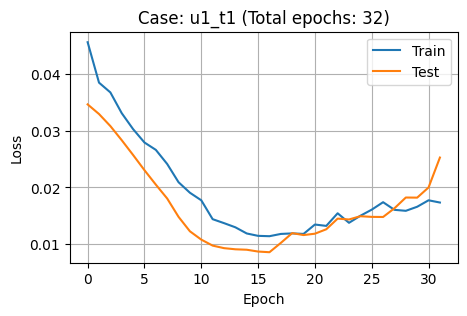

Модель u1_t1 сохранена


In [8]:
# НАСТРОЙКИ СЛУЧАЯ
CTRL_IDX, TGT_IDX = 0, 0
CASE_NAME = f"u{CTRL_IDX+1}_t{TGT_IDX+1}"
WEIGHTS_PATH = f"/content/drive/MyDrive/model_{CASE_NAME}.weights.h5"
STATE_PATH   = f"/content/drive/MyDrive/model_{CASE_NAME}_state.json"

MAX_EPOCHS = 500
PATIENCE = 15
CKPT_INTERVAL = 5
LR = 2e-4

model = create_model()
start_epoch = 0
best_val = float('inf')
patience_cnt = 0
history_tr, history_te = [], []

if os.path.exists(WEIGHTS_PATH) and os.path.exists(STATE_PATH):
    try:
        with open(STATE_PATH, 'r') as f:
            st = json.load(f)
        model.load_weights(WEIGHTS_PATH)
        start_epoch, best_val = st['epoch'], st['best_val']
        print(f"Загружено сохранение с эпохи {start_epoch}")
    except json.JSONDecodeError:
        print(f"Ошибка чтения {STATE_PATH}. Обучение с нуля.")
        _ = model(tf.zeros((1,4)))
else:
    _ = model(tf.zeros((1,4)))
    print("Запуск обучения")

optimizer = tf.keras.optimizers.Adam(learning_rate=LR)

for epoch in range(start_epoch, MAX_EPOCHS):
    # Train
    ep_tr = 0.0; nb = 0
    for bx, bC in train_ds:
        with tf.GradientTape() as tape:
            _, _, loss = simulate_and_loss(bx, bC, model, CTRL_IDX, TGT_IDX, PARAMS, TRAIN_N)
        grads = tape.gradient(loss, model.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, 1.0)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        ep_tr += loss.numpy(); nb += 1
    history_tr.append(ep_tr/nb)

    # Val
    te = 0.0; nbt = 0
    for tx, tC in test_ds:
        _, _, l = simulate_and_loss(tx, tC, model, CTRL_IDX, TGT_IDX, PARAMS, TRAIN_N)
        te += l.numpy(); nbt += 1
    history_te.append(te/nbt)

    # Early Stopping & Save
    if history_te[-1] < best_val:
        best_val = history_te[-1]; patience_cnt = 0
    else:
        patience_cnt += 1

    if (epoch+1) % 10 == 0 or epoch == start_epoch:
        print(f"Ep {epoch+1:3d} | Tr={history_tr[-1]:.4f} | Te={history_te[-1]:.4f} | Pat={patience_cnt}")

    if (epoch+1) % CKPT_INTERVAL == 0 or patience_cnt >= PATIENCE:
        model.save_weights(WEIGHTS_PATH)
        with open(STATE_PATH, 'w') as f:
            json.dump({'epoch': epoch+1, 'best_val': float(best_val)}, f)

    if patience_cnt >= PATIENCE:
        print(f"Early stopping epoch {epoch+1}")
        break

# Финальный график
plt.figure(figsize=(5,3))
plt.plot(history_tr, label='Train'); plt.plot(history_te, label='Test')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(); plt.legend()
plt.title(f"Case: {CASE_NAME} (Total epochs: {len(history_tr)})")
plt.show()
model.save_weights(WEIGHTS_PATH)
print(f"Модель {CASE_NAME} сохранена")

2

Запуск обучения
Ep   1 | Tr=0.0644 | Te=0.0600 | Pat=0
Ep  10 | Tr=0.0607 | Te=0.0602 | Pat=8
Ep  20 | Tr=0.0622 | Te=0.0600 | Pat=0
Ep  30 | Tr=0.0615 | Te=0.0601 | Pat=6
Early stopping epoch 39


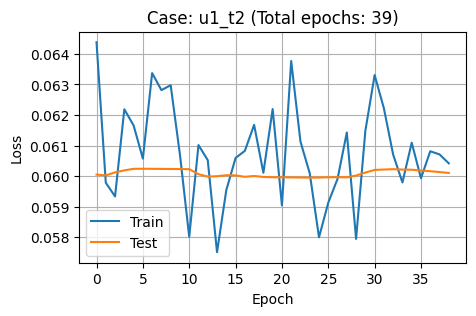

Модель u1_t2 сохранена


In [9]:
# НАСТРОЙКИ СЛУЧАЯ
CTRL_IDX, TGT_IDX = 0, 1
CASE_NAME = f"u{CTRL_IDX+1}_t{TGT_IDX+1}"
WEIGHTS_PATH = f"/content/drive/MyDrive/model_{CASE_NAME}.weights.h5"
STATE_PATH   = f"/content/drive/MyDrive/model_{CASE_NAME}_state.json"

MAX_EPOCHS = 500
PATIENCE = 15
CKPT_INTERVAL = 15
LR = 2e-4

model = create_model()
start_epoch = 0
best_val = float('inf')
patience_cnt = 0
history_tr, history_te = [], []

if os.path.exists(WEIGHTS_PATH) and os.path.exists(STATE_PATH):
    try:
        with open(STATE_PATH, 'r') as f:
            st = json.load(f)
        model.load_weights(WEIGHTS_PATH)
        start_epoch, best_val = st['epoch'], st['best_val']
        print(f"Загружено сохранение с эпохи {start_epoch}")
    except json.JSONDecodeError:
        print(f"Ошибка чтения {STATE_PATH}. Начинаю обучение с нуля.")
        _ = model(tf.zeros((1,4)))
else:
    _ = model(tf.zeros((1,4)))
    print("Запуск обучения")

optimizer = tf.keras.optimizers.Adam(learning_rate=LR)

for epoch in range(start_epoch, MAX_EPOCHS):
    # Train
    ep_tr = 0.0; nb = 0
    for bx, bC in train_ds:
        with tf.GradientTape() as tape:
            _, _, loss = simulate_and_loss(bx, bC, model, CTRL_IDX, TGT_IDX, PARAMS, TRAIN_N)
        grads = tape.gradient(loss, model.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, 1.0)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        ep_tr += loss.numpy(); nb += 1
    history_tr.append(ep_tr/nb)

    # Val
    te = 0.0; nbt = 0
    for tx, tC in test_ds:
        _, _, l = simulate_and_loss(tx, tC, model, CTRL_IDX, TGT_IDX, PARAMS, TRAIN_N)
        te += l.numpy(); nbt += 1
    history_te.append(te/nbt)

    # Early Stopping & Save
    if history_te[-1] < best_val:
        best_val = history_te[-1]; patience_cnt = 0
    else:
        patience_cnt += 1

    if (epoch+1) % 10 == 0 or epoch == start_epoch:
        print(f"Ep {epoch+1:3d} | Tr={history_tr[-1]:.4f} | Te={history_te[-1]:.4f} | Pat={patience_cnt}")

    if (epoch+1) % CKPT_INTERVAL == 0 or patience_cnt >= PATIENCE:
        model.save_weights(WEIGHTS_PATH)
        with open(STATE_PATH, 'w') as f:
            json.dump({'epoch': epoch+1, 'best_val': float(best_val)}, f)

    if patience_cnt >= PATIENCE:
        print(f"Early stopping epoch {epoch+1}")
        break

# Финальный график
plt.figure(figsize=(5,3))
plt.plot(history_tr, label='Train'); plt.plot(history_te, label='Test')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(); plt.legend()
plt.title(f"Case: {CASE_NAME} (Total epochs: {len(history_tr)})")
plt.show()
model.save_weights(WEIGHTS_PATH)
print(f"Модель {CASE_NAME} сохранена")

3

In [ ]:
CTRL_IDX, TGT_IDX = 0, 2
CASE_NAME = f"u{CTRL_IDX+1}_t{TGT_IDX+1}"
WEIGHTS_PATH = f"/content/drive/MyDrive/model_{CASE_NAME}.weights.h5"
STATE_PATH   = f"/content/drive/MyDrive/model_{CASE_NAME}_state.json"

MAX_EPOCHS, PATIENCE, CKPT_INTERVAL, LR = 500, 15, 15, 2e-4
model = create_model()
start_epoch, best_val, patience_cnt = 0, float('inf'), 0
history_tr, history_te = [], []

if os.path.exists(WEIGHTS_PATH) and os.path.exists(STATE_PATH):
    try:
        with open(STATE_PATH, 'r') as f: st = json.load(f)
        model.load_weights(WEIGHTS_PATH)
        start_epoch, best_val = st['epoch'], st['best_val']
        print(f"Загружено сохранение с эпохи {start_epoch}")
    except json.JSONDecodeError:
        print(f"Ошибка чтения {STATE_PATH}. Начинаю обучение с нуля.")
        _ = model(tf.zeros((1,4)))
else:
    _ = model(tf.zeros((1,4))); print("Запуск обучения")

optimizer = tf.keras.optimizers.Adam(learning_rate=LR)
for epoch in range(start_epoch, MAX_EPOCHS):
    ep_tr = 0.0; nb = 0
    for bx, bC in train_ds:
        with tf.GradientTape() as tape:
            _, _, loss = simulate_and_loss(bx, bC, model, CTRL_IDX, TGT_IDX, PARAMS, TRAIN_N)
        grads = tape.gradient(loss, model.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, 1.0)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        ep_tr += loss.numpy(); nb += 1
    history_tr.append(ep_tr/nb)
    te = 0.0; nbt = 0
    for tx, tC in test_ds:
        _, _, l = simulate_and_loss(tx, tC, model, CTRL_IDX, TGT_IDX, PARAMS, TRAIN_N)
        te += l.numpy(); nbt += 1
    history_te.append(te/nbt)
    if history_te[-1] < best_val: best_val = history_te[-1]; patience_cnt = 0
    else: patience_cnt += 1
    if (epoch+1) % 10 == 0 or epoch == start_epoch:
        print(f"Ep {epoch+1:3d} | Tr={history_tr[-1]:.4f} | Te={history_te[-1]:.4f} | Pat={patience_cnt}")
    if (epoch+1) % CKPT_INTERVAL == 0 or patience_cnt >= PATIENCE:
        model.save_weights(WEIGHTS_PATH)
        with open(STATE_PATH, 'w') as f: json.dump({'epoch': epoch+1, 'best_val': float(best_val)}, f)
    if patience_cnt >= PATIENCE: print(f"Early stopping {epoch+1}"); break
plt.figure(figsize=(5,3)); plt.plot(history_tr, label='Train'); plt.plot(history_te, label='Test')
plt.grid(); plt.legend(); plt.title(f"Case: {CASE_NAME}"); plt.show()
model.save_weights(WEIGHTS_PATH); print(f"Сохранено {CASE_NAME}")

Запуск обучения
Ep   1 | Tr=0.2891 | Te=0.2234 | Pat=0
Ep  10 | Tr=0.1685 | Te=0.1209 | Pat=0
Ep  20 | Tr=0.1522 | Te=0.1121 | Pat=0
Ep  30 | Tr=0.1498 | Te=0.1102 | Pat=0
Ep  40 | Tr=0.1470 | Te=0.1099 | Pat=0
Ep  50 | Tr=0.1462 | Te=0.1098 | Pat=0
Ep  60 | Tr=0.1484 | Te=0.1097 | Pat=0
Ep  70 | Tr=0.1550 | Te=0.1097 | Pat=0
Ep  80 | Tr=0.1477 | Te=0.1096 | Pat=0


4

In [ ]:
CTRL_IDX, TGT_IDX = 1, 0
CASE_NAME = f"u{CTRL_IDX+1}_t{TGT_IDX+1}"
WEIGHTS_PATH = f"/content/drive/MyDrive/model_{CASE_NAME}.weights.h5"
STATE_PATH   = f"/content/drive/MyDrive/model_{CASE_NAME}_state.json"

MAX_EPOCHS, PATIENCE, CKPT_INTERVAL, LR = 500, 15, 15, 2e-4
model = create_model()
start_epoch, best_val, patience_cnt = 0, float('inf'), 0
history_tr, history_te = [], []

if os.path.exists(WEIGHTS_PATH) and os.path.exists(STATE_PATH):
    try:
        with open(STATE_PATH, 'r') as f: st = json.load(f)
        model.load_weights(WEIGHTS_PATH)
        start_epoch, best_val = st['epoch'], st['best_val']
        print(f"Загружено сохранение с эпохи {start_epoch}")
    except json.JSONDecodeError:
        print(f"Ошибка чтения {STATE_PATH}. Начинаю обучение с нуля.")
        _ = model(tf.zeros((1,4)))
else:
    _ = model(tf.zeros((1,4))); print("Запуск обучения")

optimizer = tf.keras.optimizers.Adam(learning_rate=LR)
for epoch in range(start_epoch, MAX_EPOCHS):
    ep_tr = 0.0; nb = 0
    for bx, bC in train_ds:
        with tf.GradientTape() as tape:
            _, _, loss = simulate_and_loss(bx, bC, model, CTRL_IDX, TGT_IDX, PARAMS, TRAIN_N)
        grads = tape.gradient(loss, model.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, 1.0)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        ep_tr += loss.numpy(); nb += 1
    history_tr.append(ep_tr/nb)
    te = 0.0; nbt = 0
    for tx, tC in test_ds:
        _, _, l = simulate_and_loss(tx, tC, model, CTRL_IDX, TGT_IDX, PARAMS, TRAIN_N)
        te += l.numpy(); nbt += 1
    history_te.append(te/nbt)
    if history_te[-1] < best_val: best_val = history_te[-1]; patience_cnt = 0
    else: patience_cnt += 1
    if (epoch+1) % 10 == 0 or epoch == start_epoch:
        print(f"Ep {epoch+1:3d} | Tr={history_tr[-1]:.4f} | Te={history_te[-1]:.4f} | Pat={patience_cnt}")
    if (epoch+1) % CKPT_INTERVAL == 0 or patience_cnt >= PATIENCE:
        model.save_weights(WEIGHTS_PATH)
        with open(STATE_PATH, 'w') as f: json.dump({'epoch': epoch+1, 'best_val': float(best_val)}, f)
    if patience_cnt >= PATIENCE: print(f"Early stopping {epoch+1}"); break
plt.figure(figsize=(5,3)); plt.plot(history_tr, label='Train'); plt.plot(history_te, label='Test')
plt.grid(); plt.legend(); plt.title(f"Case: {CASE_NAME}"); plt.show()
model.save_weights(WEIGHTS_PATH); print(f"Сохранено {CASE_NAME}")

5

In [ ]:
CTRL_IDX, TGT_IDX = 1, 1
CASE_NAME = f"u{CTRL_IDX+1}_t{TGT_IDX+1}"
WEIGHTS_PATH = f"/content/drive/MyDrive/model_{CASE_NAME}.weights.h5"
STATE_PATH   = f"/content/drive/MyDrive/model_{CASE_NAME}_state.json"

MAX_EPOCHS, PATIENCE, CKPT_INTERVAL, LR = 500, 15, 15, 2e-4
model = create_model()
start_epoch, best_val, patience_cnt = 0, float('inf'), 0
history_tr, history_te = [], []

if os.path.exists(WEIGHTS_PATH) and os.path.exists(STATE_PATH):
    try:
        with open(STATE_PATH, 'r') as f: st = json.load(f)
        model.load_weights(WEIGHTS_PATH)
        start_epoch, best_val = st['epoch'], st['best_val']
        print(f"Загружено сохранение с эпохи {start_epoch}")
    except json.JSONDecodeError:
        print(f"Ошибка чтения {STATE_PATH}. Начинаю обучение с нуля.")
        _ = model(tf.zeros((1,4)))
else:
    _ = model(tf.zeros((1,4))); print("Запуск обучения")

optimizer = tf.keras.optimizers.Adam(learning_rate=LR)
for epoch in range(start_epoch, MAX_EPOCHS):
    ep_tr = 0.0; nb = 0
    for bx, bC in train_ds:
        with tf.GradientTape() as tape:
            _, _, loss = simulate_and_loss(bx, bC, model, CTRL_IDX, TGT_IDX, PARAMS, TRAIN_N)
        grads = tape.gradient(loss, model.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, 1.0)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        ep_tr += loss.numpy(); nb += 1
    history_tr.append(ep_tr/nb)
    te = 0.0; nbt = 0
    for tx, tC in test_ds:
        _, _, l = simulate_and_loss(tx, tC, model, CTRL_IDX, TGT_IDX, PARAMS, TRAIN_N)
        te += l.numpy(); nbt += 1
    history_te.append(te/nbt)
    if history_te[-1] < best_val: best_val = history_te[-1]; patience_cnt = 0
    else: patience_cnt += 1
    if (epoch+1) % 10 == 0 or epoch == start_epoch:
        print(f"Ep {epoch+1:3d} | Tr={history_tr[-1]:.4f} | Te={history_te[-1]:.4f} | Pat={patience_cnt}")
    if (epoch+1) % CKPT_INTERVAL == 0 or patience_cnt >= PATIENCE:
        model.save_weights(WEIGHTS_PATH)
        with open(STATE_PATH, 'w') as f: json.dump({'epoch': epoch+1, 'best_val': float(best_val)}, f)
    if patience_cnt >= PATIENCE: print(f"Early stopping {epoch+1}"); break
plt.figure(figsize=(5,3)); plt.plot(history_tr, label='Train'); plt.plot(history_te, label='Test')
plt.grid(); plt.legend(); plt.title(f"Case: {CASE_NAME}"); plt.show()
model.save_weights(WEIGHTS_PATH); print(f"Сохранено {CASE_NAME}")

6

In [ ]:
CTRL_IDX, TGT_IDX = 1, 2
CASE_NAME = f"u{CTRL_IDX+1}_t{TGT_IDX+1}"
WEIGHTS_PATH = f"/content/drive/MyDrive/model_{CASE_NAME}.weights.h5"
STATE_PATH   = f"/content/drive/MyDrive/model_{CASE_NAME}_state.json"

MAX_EPOCHS, PATIENCE, CKPT_INTERVAL, LR = 500, 15, 15, 2e-4
model = create_model()
start_epoch, best_val, patience_cnt = 0, float('inf'), 0
history_tr, history_te = [], []

if os.path.exists(WEIGHTS_PATH) and os.path.exists(STATE_PATH):
    try:
        with open(STATE_PATH, 'r') as f: st = json.load(f)
        model.load_weights(WEIGHTS_PATH)
        start_epoch, best_val = st['epoch'], st['best_val']
        print(f"Загружено сохранение с эпохи {start_epoch}")
    except json.JSONDecodeError:
        print(f"Ошибка чтения {STATE_PATH}. Начинаю обучение с нуля.")
        _ = model(tf.zeros((1,4)))
else:
    _ = model(tf.zeros((1,4))); print("Запуск обучения")

optimizer = tf.keras.optimizers.Adam(learning_rate=LR)
for epoch in range(start_epoch, MAX_EPOCHS):
    ep_tr = 0.0; nb = 0
    for bx, bC in train_ds:
        with tf.GradientTape() as tape:
            _, _, loss = simulate_and_loss(bx, bC, model, CTRL_IDX, TGT_IDX, PARAMS, TRAIN_N)
        grads = tape.gradient(loss, model.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, 1.0)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        ep_tr += loss.numpy(); nb += 1
    history_tr.append(ep_tr/nb)
    te = 0.0; nbt = 0
    for tx, tC in test_ds:
        _, _, l = simulate_and_loss(tx, tC, model, CTRL_IDX, TGT_IDX, PARAMS, TRAIN_N)
        te += l.numpy(); nbt += 1
    history_te.append(te/nbt)
    if history_te[-1] < best_val: best_val = history_te[-1]; patience_cnt = 0
    else: patience_cnt += 1
    if (epoch+1) % 10 == 0 or epoch == start_epoch:
        print(f"Ep {epoch+1:3d} | Tr={history_tr[-1]:.4f} | Te={history_te[-1]:.4f} | Pat={patience_cnt}")
    if (epoch+1) % CKPT_INTERVAL == 0 or patience_cnt >= PATIENCE:
        model.save_weights(WEIGHTS_PATH)
        with open(STATE_PATH, 'w') as f: json.dump({'epoch': epoch+1, 'best_val': float(best_val)}, f)
    if patience_cnt >= PATIENCE: print(f"Early stopping {epoch+1}"); break
plt.figure(figsize=(5,3)); plt.plot(history_tr, label='Train'); plt.plot(history_te, label='Test')
plt.grid(); plt.legend(); plt.title(f"Case: {CASE_NAME}"); plt.show()
model.save_weights(WEIGHTS_PATH); print(f"Сохранено {CASE_NAME}")

демонстрация

Загружена модель: u1_t2


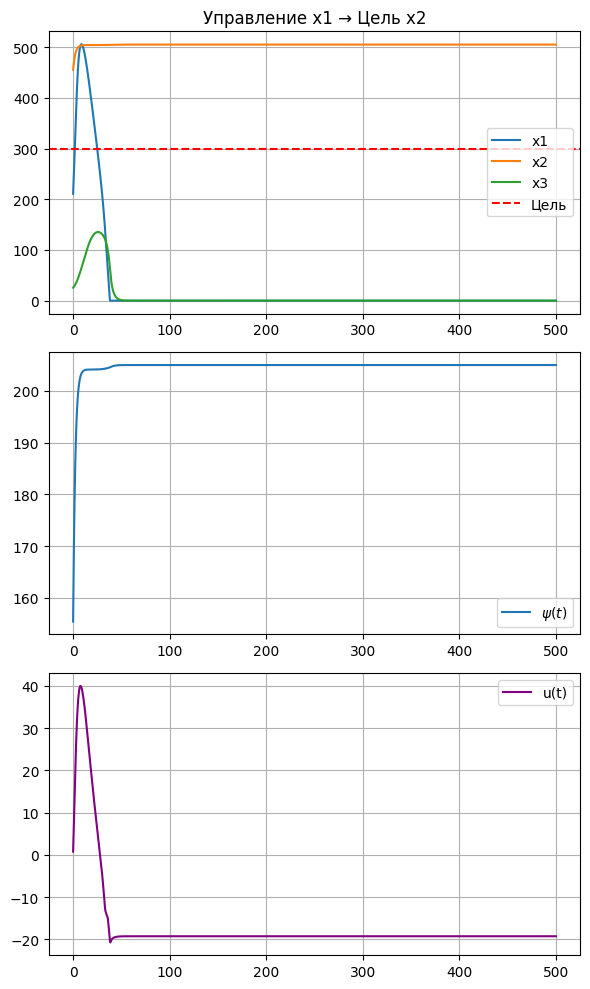

In [13]:
import numpy as np, matplotlib.pyplot as plt

# 🔧 ВЫБЕРИТЕ СЛУЧАЙ ЗДЕСЬ (0 или 1 для управления, 0/1/2 для цели)
DEMO_CTRL, DEMO_TGT = 0, 1
CASE_NAME = f"u{DEMO_CTRL+1}_t{DEMO_TGT+1}"
WEIGHTS_PATH = f"/content/drive/MyDrive/model_{CASE_NAME}.weights.h5"

if not os.path.exists(WEIGHTS_PATH):
    raise FileNotFoundError(f"Модель {CASE_NAME} еще не обучена. Запустите соответствующую ячейку.")

model = create_model()
_ = model(tf.zeros((1,4)))
model.load_weights(WEIGHTS_PATH)
print(f"Загружена модель: {CASE_NAME}")

# Точная симуляция
x0 = np.array([[200.0, 450.0, 25.0]], np.float32)
C0 = np.array([[300.0]], np.float32)
x = x0; tr, ur = [], []
dt_sim = T / DEMO_N
for _ in range(DEMO_N):
    x_norm = x / X_SCALE; C_norm = C0 / C_SCALE
    inp = tf.concat([x_norm, C_norm], axis=-1)
    u_norm = tf.squeeze(model(inp), axis=-1)
    u_scaled = u_norm * U_MAX
    dx = dynamics(x, u_scaled, DEMO_CTRL, PARAMS)
    x = x + dt_sim * dx
    x = tf.clip_by_value(x, 1e-3, 2000.0)
    tr.append(x); ur.append(u_scaled)

traj = tf.stack(tr, axis=1).numpy()[0]
u_traj = tf.stack(ur, axis=1).numpy()[0]
ts = np.linspace(0, T, len(u_traj))
psi = traj[:, DEMO_TGT] - C0[0,0]

plt.figure(figsize=(6,10))
plt.subplot(3,1,1)
for i, lbl in enumerate(['x1','x2','x3']): plt.plot(ts, traj[:,i], label=lbl)
plt.axhline(C0[0,0], color='red', ls='--', label='Цель'); plt.grid(); plt.legend()
plt.title(f"Управление x{DEMO_CTRL+1} → Цель x{DEMO_TGT+1}")
plt.subplot(3,1,2); plt.plot(ts, psi, label=r'$\psi(t)$'); plt.grid(); plt.legend()
plt.subplot(3,1,3); plt.plot(ts, u_traj, label='u(t)', color='purple'); plt.grid(); plt.legend()
plt.tight_layout(); plt.show()